In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("Placement_Data_Full_Class1.csv")

In [3]:
dataset.shape

(215, 15)

In [4]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [5]:
dataset["status"].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

In [6]:
dataset=dataset.fillna(0)

In [7]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [8]:
quan=[]
qual=[]
for columnName in dataset:
    if dataset[columnName].dtypes=="O":
        qual.append(columnName)
    else:
        quan.append(columnName)

In [9]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Max","Min","25%","50%","75%","100%","IQR","1.5IQR","LesserRange","GreaterRange"],columns=quan)

In [10]:
for columnName in quan:
    descriptive.loc["Mean",columnName]=dataset[columnName].mean()
    descriptive.loc["Median",columnName]=dataset[columnName].median()
    descriptive.loc["Mode",columnName]=dataset[columnName].mode()[0]
    descriptive.loc["Max",columnName]=dataset[columnName].max()
    descriptive.loc["Min",columnName]=dataset[columnName].min()

    descriptive.loc["25%",columnName]=dataset.describe()[columnName]["25%"]
    descriptive.loc["50%",columnName]=dataset.describe()[columnName]["50%"]
    descriptive.loc["75%",columnName]=dataset.describe()[columnName]["75%"]
    descriptive.loc["100%",columnName]=dataset.describe()[columnName]["max"]

    descriptive.loc["IQR",columnName]=descriptive.loc["75%",columnName]-descriptive.loc["25%",columnName]
    descriptive.loc["1.5IQR",columnName]=1.5*descriptive.loc["IQR",columnName]
    descriptive.loc["LesserRange",columnName]=descriptive.loc["25%",columnName]-descriptive.loc["1.5IQR",columnName]
    descriptive.loc["GreaterRange",columnName]=descriptive.loc["75%",columnName]+descriptive.loc["1.5IQR",columnName]

In [11]:
descriptive

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.0,67.303395,66.333163,66.370186,72.100558,62.278186,198702.325581
Median,108.0,67.0,65.0,66.0,71.0,62.0,240000.0
Mode,1,62.0,63.0,65.0,60.0,56.7,0.0
Max,215,89.4,97.7,91.0,98.0,77.89,940000.0
Min,1,40.89,37.0,50.0,50.0,51.21,0.0
25%,54.5,60.6,60.9,61.0,60.0,57.945,0.0
50%,108.0,67.0,65.0,66.0,71.0,62.0,240000.0
75%,161.5,75.7,73.0,72.0,83.5,66.255,282500.0
100%,215.0,89.4,97.7,91.0,98.0,77.89,940000.0
IQR,107.0,15.1,12.1,11.0,23.5,8.31,282500.0


In [12]:
lesser=[]
greater=[]
for columnName in quan:
    if (descriptive.loc["Min",columnName]<descriptive.loc["LesserRange",columnName]):
        lesser.append(columnName)
    if(descriptive.loc["Max",columnName]>descriptive.loc["GreaterRange",columnName]):
        greater.append(columnName)

In [13]:
lesser

['hsc_p']

In [14]:
greater

['hsc_p', 'degree_p', 'salary']

In [15]:
for columnName in quan:
    lower = descriptive.loc["LesserRange", columnName]
    upper = descriptive.loc["GreaterRange", columnName]
    dataset[columnName]=dataset[columnName].clip(lower=lower,upper=upper)

In [16]:
for columnName in quan:
    descriptive.loc["Mean",columnName]=dataset[columnName].mean()
    descriptive.loc["Median",columnName]=dataset[columnName].median()
    descriptive.loc["Mode",columnName]=dataset[columnName].mode()[0]
    descriptive.loc["Max",columnName]=dataset[columnName].max()
    descriptive.loc["Min",columnName]=dataset[columnName].min()

    descriptive.loc["25%",columnName]=dataset.describe()[columnName]["25%"]
    descriptive.loc["50%",columnName]=dataset.describe()[columnName]["50%"]
    descriptive.loc["75%",columnName]=dataset.describe()[columnName]["75%"]
    descriptive.loc["100%",columnName]=dataset.describe()[columnName]["max"]

    descriptive.loc["IQR",columnName]=descriptive.loc["75%",columnName]-descriptive.loc["25%",columnName]
    descriptive.loc["1.5IQR",columnName]=1.5*descriptive.loc["IQR",columnName]
    descriptive.loc["LesserRange",columnName]=descriptive.loc["25%",columnName]-descriptive.loc["1.5IQR",columnName]
    descriptive.loc["GreaterRange",columnName]=descriptive.loc["75%",columnName]+descriptive.loc["1.5IQR",columnName]

In [17]:
lesser=[]
greater=[]
for columnName in quan:
    if (descriptive.loc["Min",columnName]<descriptive.loc["LesserRange",columnName]):
        lesser.append(columnName)
    if(descriptive.loc["Max",columnName]>descriptive.loc["GreaterRange",columnName]):
        greater.append(columnName)

In [18]:
lesser

[]

In [19]:
greater

[]

In [20]:
dataset[quan].corr()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,1.000000,-0.078155,-0.090500,-0.091039,0.063636,0.022327,0.001217
ssc_p,-0.078155,1.000000,0.513478,0.538686,0.261993,0.388478,0.558475
hsc_p,-0.090500,0.513478,1.000000,0.434606,0.240775,0.348452,0.459424
degree_p,-0.091039,0.538686,0.434606,1.000000,0.227147,0.402376,0.423762
etest_p,0.063636,0.261993,0.240775,0.227147,1.000000,0.218055,0.186775
mba_p,0.022327,0.388478,0.348452,0.402376,0.218055,1.000000,0.141417
salary,0.001217,0.558475,0.459424,0.423762,0.186775,0.141417,1.000000


In [21]:
dataset["specialisation"].value_counts()

specialisation
Mkt&Fin    120
Mkt&HR      95
Name: count, dtype: int64

In [23]:
dataset.groupby("specialisation")["salary"].mean()

specialisation
Mkt&Fin    234643.750000
Mkt&HR     150842.105263
Name: salary, dtype: float64

In [33]:
(dataset["salary"] > 500000 ).sum()

3

In [37]:
from scipy.stats import f_oneway
f_oneway(dataset["etest_p"],dataset["mba_p"])

F_onewayResult(statistic=98.64487057324706, pvalue=4.672547689133573e-21)

In [40]:
#degree_t(Sci&Tech) and specialisation (Mkt&HR) 

In [43]:
from scipy.stats import ttest_ind
degree=dataset[dataset["degree_t"]=="Sci&Tech"]["salary"]
spec=dataset[dataset["specialisation"]=="Mkt&HR"]["salary"]
ttest_ind(degree,spec)

TtestResult(statistic=2.692041243555374, pvalue=0.007897969943471179, df=152.0)

In [44]:
from scipy.stats import ttest_rel
degree=dataset[dataset["degree_t"]=="Sci&Tech"]["etest_p"]
degree1=dataset[dataset["degree_t"]=="Sci&Tech"]["mba_p"]
ttest_rel(degree,degree1)

TtestResult(statistic=5.0049844583693615, pvalue=5.517920600505392e-06, df=58)

In [46]:
quan

['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

In [50]:
dataset[quan].corr()["salary"]

sl_no       0.001217
ssc_p       0.558475
hsc_p       0.459424
degree_p    0.423762
etest_p     0.186775
mba_p       0.141417
salary      1.000000
Name: salary, dtype: float64

In [62]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='green')
    pyplot.axvline(startrange,color='red')
    pyplot.axvline(endrange,color='red')
    #generate sample
    sample=dataset
    #calc parameters
    sample_mean=sample.mean()
    sample_std=sample.std()
    print("Mean=%3.f,Standard Deviation=%.3f"%(sample_mean,sample_std))
    prob = norm.cdf(endrange, sample_mean, sample_std) - \
           norm.cdf(startrange, sample_mean, sample_std)
    print("The area between the range({},{}):{}".format(startrange,endrange,prob))
    return prob

Mean=197615,Standard Deviation=150305.844
The area between the range(700000,900000):0.00041377631316941166


C:\Users\SS\AppData\Local\Temp\ipykernel_22072\3081650658.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='green')


0.00041377631316941166

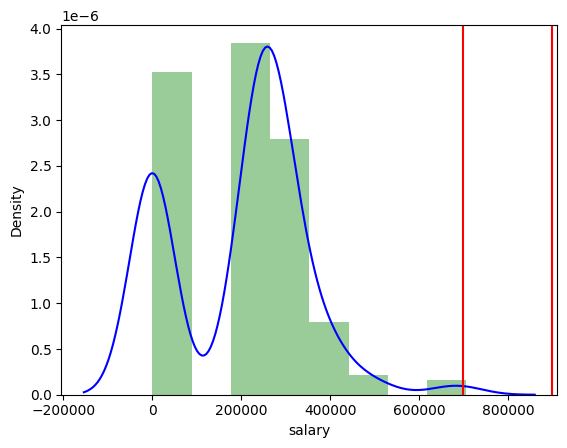

In [64]:
get_pdf_probability(dataset["salary"],700000,900000)

In [65]:
def stdNBgraph(dataset):
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()
    values=[i for i in dataset]
    z_scores=[((j-mean)/std) for j in values]
    sns.distplot(z_scores,kde=True)
    sum(z_scores)/len(z_scores)

C:\Users\SS\AppData\Local\Temp\ipykernel_22072\3627566422.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_scores,kde=True)


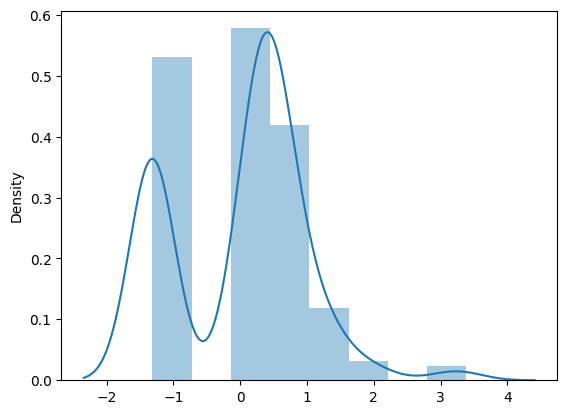

In [68]:
stdNBgraph(dataset["salary"])

In [70]:
dataset.groupby("status")[["ssc_p","hsc_p","degree_p","etest_p","mba_p"]].mean()

,ssc_p,hsc_p,degree_p,etest_p,mba_p
status,,,,,
Not Placed,57.544030,58.598358,61.134179,69.587910,61.612836
Placed,71.721486,69.837027,68.723649,73.238041,62.579392


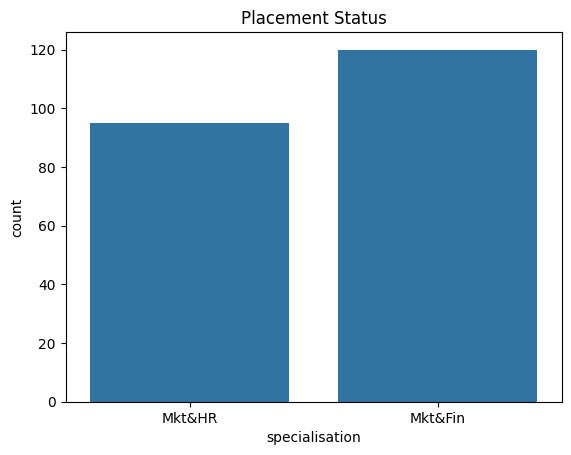

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="specialisation", data=dataset)
plt.title("Placement Status")
plt.show()